In [1]:
from astropy.coordinates import ICRS
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time, TimeDelta
from astropy.coordinates import EarthLocation
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import ICRS
from src.load_params import *
from src.scan_fcts import *

P = load_params('PAR_files/params_strategy.par')

name=P['name_field']
c=SkyCoord.from_name(name)
ra = 0 
dec = c.dec.value

#load the observer position
lat = P['latitude']

#Load the scan duration and generate the time coordinates with the desired acquisition rate. 
T_duration = P['T_duration'] 
dt = P['dt']*np.pi/3.14 #Make the timestep non rational to avoid some stripes in the hitmap. 
spf = int(1/np.round(dt*3600,3)) #sample per frame defined here as the acquisition rate in Hz. 

HA = np.arange(-T_duration/2, T_duration/2, dt)  # in hours
#LST = np.arange(-T_duration/2,T_duration/2,dt) #hours

T = np.arange(0, T_duration, dt) * 3600  # seconds

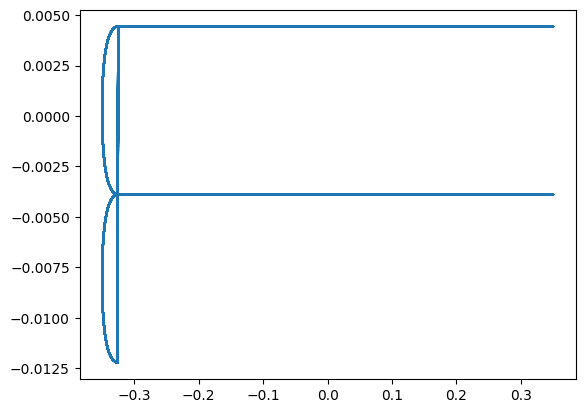

In [2]:
az, alt, flag = genLocalPath_cst_el_scan(az_size=P['az_size'], alt_size=P['alt_size'], alt_step=P['alt_step'], acc=P['acc'], scan_v=P['scan_v'], dt=np.round(dt*3600,3))
scan_path, scan_flag = genScanPath(T, alt, az, flag)
plt.plot(scan_path[:,0],scan_path[:,1] )

In [3]:
#------------------------
# Constants
decr = np.radians(dec)  # DEC offset due to scanning [rad]
latr = np.radians(lat)             # Observer latitude  [rad]
#HA = ha.copy() # Hour angle [hour]
HAr = HA * np.pi / 12 # Hour angle [rad]
HAd = np.degrees(HAr) # Hour angle [deg]

# Precompute trigonometric terms
sin_dec = np.sin(decr)
cos_dec = np.cos(decr)
sin_lat = np.sin(latr)
cos_lat = np.cos(latr)
cos_HA = np.cos(HAr)
sin_HA = np.sin(HAr)
#------------------------

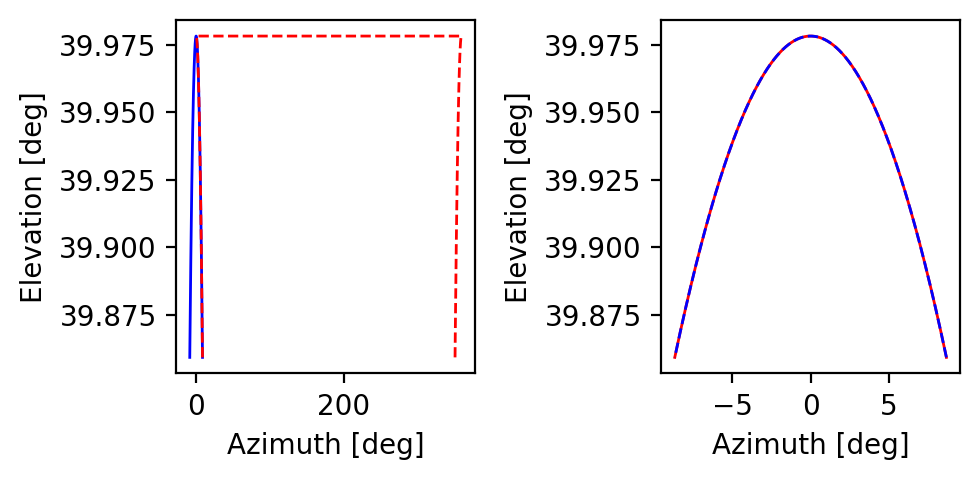

In [4]:
#NAMAP formula
#-------------------
el = np.arcsin(sin_dec*sin_lat+cos_lat*cos_dec*cos_HA) 
az = np.arccos((sin_dec-sin_lat*np.sin(el))/(cos_lat*np.cos(el)))
index, = np.where(sin_HA>0)
az[index] = 2*np.pi - az[index]
#-----------

#Strategy formula
#-----------
cos_za = sin_lat * sin_dec + cos_lat * cos_dec * cos_HA
za = np.arccos(cos_za)
sin_za = np.sin(za)
alti = np.pi/2 - za
cosAz = (sin_dec - sin_lat * cos_za)/(cos_lat * sin_za)
sinAz =  - sin_HA * cos_dec/ sin_za
azi = np.arctan2(sinAz,cosAz)
#-----------

# "Unwrap" from [0, 2π) to (-π, π]
#---------------------------------------------------
azi_unwrapped = (azi + np.pi) % (2 * np.pi) - np.pi
az_unwrapped  = (az  + np.pi) % (2 * np.pi) - np.pi
#---------------------------------------------------

fig, axs = plt.subplots(1,2,figsize=(5,2.5),dpi=200)
axs[0].plot(np.degrees(azi), np.degrees(alti), c='b', lw=1, ls='-')
axs[0].plot(np.degrees(az), np.degrees(el), c='r', lw=1, ls='--')
axs[0].set_xlabel("Azimuth [deg]")
axs[0].set_ylabel("Elevation [deg]")
axs[1].plot(np.degrees(az_unwrapped), np.degrees(el), c='r', lw=1, ls='-')
axs[1].plot(np.degrees(azi_unwrapped),      np.degrees(alti),      c='b', lw=1, ls='--')
axs[1].set_xlabel("Azimuth [deg]")
axs[1].set_ylabel("Elevation [deg]")
#---
plt.tight_layout()
plt.show()

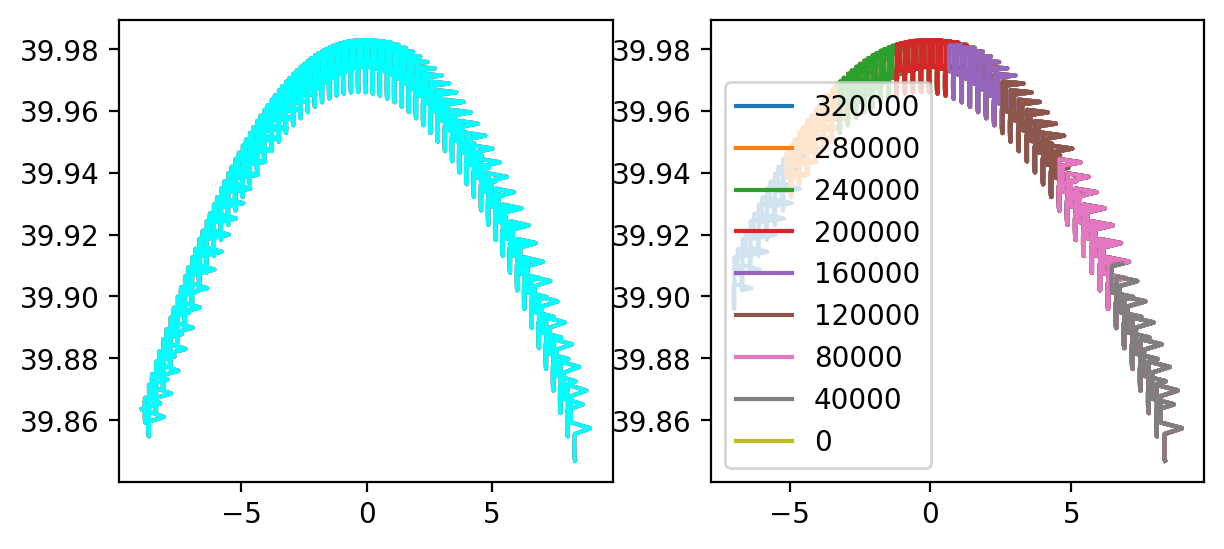

In [5]:
# Apply scan offsets to (az_c, alt_c)
# These are small-angle offsets in azimuth and altitude
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(7,3),dpi=200)

#3) Namap formula
el_tot = el + np.radians(scan_path[:, 1])
az_tot = az + np.radians(scan_path[:, 0])
az_tot_unwrapped = (az_tot + np.pi) % (2 * np.pi) - np.pi
ax1.plot(np.degrees(az_tot_unwrapped), np.degrees(el_tot), 'r') 

#1) Strategy formula
alti_tot = alti + np.radians(scan_path[:,1])
azi_tot  = azi  + np.radians(scan_path[:,0]) 
azi_unwrapped = (azi_tot + np.pi) % (2 * np.pi) - np.pi
ax1.plot(np.degrees(azi_unwrapped),    np.degrees(alti_tot), 'b') 

for t in reversed(np.arange(len(alti_tot))[::40000]):
    ax2.plot(np.degrees(azi_unwrapped)[:t], np.degrees(alti_tot)[:t], label=t)
ax2.legend()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


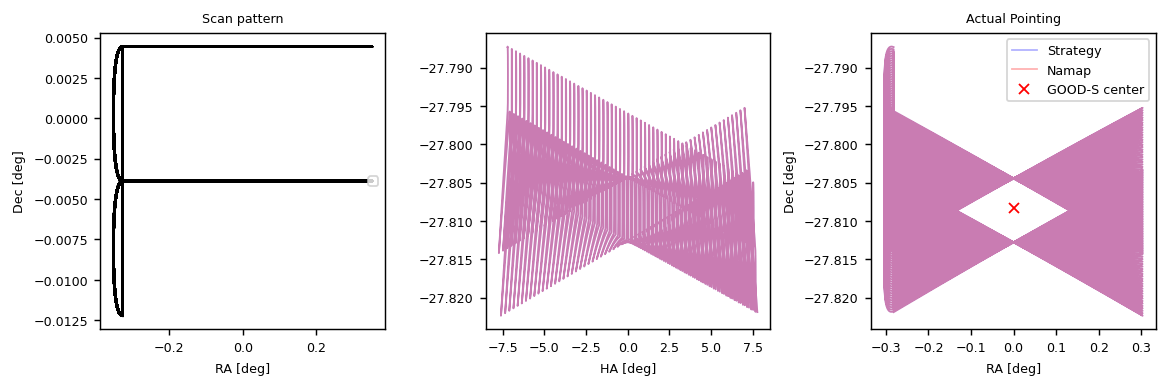

In [6]:
dec_tot = declinationAngle(np.degrees(azi_tot), np.degrees(alti_tot), lat)
hour_angle_TOT = hourAngle(np.degrees(azi_tot), np.degrees(alti_tot), lat)
RA_tot = np.degrees((HA*np.pi/12 - hour_angle_TOT))
ra_tot_unwrapped = ( np.radians(RA_tot) + np.pi) % (2 * np.pi) - np.pi

#------------------------------------------------------------------------------
# Function to convert AZ and EL to RA and DEC
sin_dec_namap = np.sin(el_tot)*sin_lat+cos_lat*np.cos(el_tot)*np.cos(az_tot)
dec_namap = np.arcsin(sin_dec_namap)

cos_hour_angle = (np.sin(el_tot)-sin_lat*sin_dec_namap)/(cos_lat*np.cos(dec_namap))
hour_angle = np.arccos(cos_hour_angle)
index, = np.where(np.sin(az_tot) > 0)
hour_angle[index] = 2*np.pi - hour_angle[index]

ra_namap = (HA - np.degrees(hour_angle)/15.)*15.

index, = np.where(ra_namap<0)
ra_namap[index] += 360.

ra_namap_unwrapped = ( np.radians(ra_namap) + np.pi) % (2 * np.pi) - np.pi
path_namap = np.vstack((np.degrees(ra_namap_unwrapped),np.degrees(dec_namap))).T

BS=7; plt.rc('font', size=BS); plt.rc('axes', titlesize=BS); plt.rc('axes', labelsize=BS); 
fig, axs = plt.subplots(1,3,figsize=(9,3),dpi=130)

axs[0].plot(scan_path[:,0],scan_path[:,1],c='k' )
axs[0].set_xlabel('Path RA [deg]');axs[0].set_ylabel('Path Dec [deg]')
axs[0].set_title('Scan pattern')

ha_unwrapped = ( hour_angle_TOT + np.pi) % (2 * np.pi) - np.pi
axs[1].plot( np.degrees(ha_unwrapped), np.degrees(dec_namap), 'b', lw=1, alpha=0.3, label='Strategy')
ha_unwrapped = ( hour_angle + np.pi) % (2 * np.pi) - np.pi
axs[1].plot( np.degrees(ha_unwrapped), np.degrees(dec_namap), 'r', lw=1, alpha=0.3, label='Namap')
axs[1].set_xlabel('HA [deg]');axs[0].set_ylabel('Dec [deg]')


axs[2].set_title('Actual Pointing')
axs[2].plot(np.degrees(ra_tot_unwrapped), np.degrees(dec_tot), 'b', lw=1, alpha=0.3, label='Strategy')
axs[2].plot(path_namap[:,0], path_namap[:,1], 'r', lw=1, alpha=0.3, label='Namap')
axs[2].plot(ra,dec, 'xr', label='GOOD-S center')
axs[2].set_xlabel('RA [deg]');axs[2].set_ylabel('Dec [deg]')
axs[2].legend()
#axs[1,0].plot(path[:,0]-path_namap[:,0], path[:,1]-path_namap[:,1], 'r', lw=1, alpha=0.3, label='Strategy-Namap')
axs[0].set_xlabel('RA [deg]');axs[0].set_ylabel('Dec [deg]');axs[0].legend(loc='center right')

'''
def F(x): return (x*u.deg).to(u.arcsec).value
secax = axs[0].secondary_xaxis("top", functions=(F,F))
secax.set_xlabel('delta RA [arcsec]')
secax = axs[0].secondary_yaxis("right", functions=(F,F))
secax.set_ylabel('delta Dec [arcsec]')
'''
plt.tight_layout()